# Deteção de Fraude com Machine Learning

O objetivo é perceber qual dos modelos supervisionados consegue distinguir melhor os casos positivos dos casos negativos em dois contextos financeiros diferentes.

## 1. Objetivo do trabalho

O trabalho compara três modelos de classificação supervisionada:

- **Logistic Regression**;
- **Decision Tree**;
- **Random Forest**.

A comparação é feita nos mesmos conjuntos de dados e com as mesmas métricas. Assim, é possível perceber qual dos modelos apresenta o melhor equilíbrio entre acertar nos casos positivos e evitar falsos alarmes.

In [1]:
from pathlib import Path
import sys

# Permite executar o notebook a partir da raiz do projeto.
CURRENT = Path.cwd()
if (CURRENT / "src").exists():
    PROJECT_ROOT = CURRENT
elif (CURRENT.parent / "src").exists():
    PROJECT_ROOT = CURRENT.parent
else:
    raise FileNotFoundError("Não foi possível encontrar a pasta src do projeto.")

sys.path.insert(0, str(PROJECT_ROOT))
print("Projeto carregado com sucesso.")

Projeto carregado com sucesso.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score

from src.fraud_modeling import (
    DATASETS,
    MODELS,
    load_dataset,
    evaluate_dataset,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Conjuntos de dados utilizados

Foram utilizados dois conjuntos de dados:

- **Bank Marketing**: usado como conjunto de comparação. Representa um problema financeiro mais equilibrado, em que o objetivo é prever se um cliente aderiu ou não a um depósito.
- **Credit Card Fraud**: usado como conjunto principal ligado à deteção de fraude. O objetivo é distinguir transações normais de transações fraudulentas.

A utilização destes dois conjuntos permite comparar os mesmos modelos em dois cenários diferentes: um mais equilibrado e outro mais difícil, com poucas fraudes.

In [3]:
# Carregar datasets e criar resumo geral
loaded = {}
summary_rows = []

for name, cfg in DATASETS.items():
    X, y = load_dataset(name, cfg)
    loaded[name] = (X, y)
    counts = y.value_counts().sort_index()
    summary_rows.append({
        "dataset": name,
        "registos": len(X),
        "atributos": X.shape[1],
        "casos_negativos": int(counts.get(0, 0)),
        "casos_positivos": int(counts.get(1, 0)),
        "percentagem_positiva": y.mean(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,dataset,registos,atributos,casos_negativos,casos_positivos,percentagem_positiva
0,Credit Card Fraud,15492,30,15000,492,0.031758
1,Bank Marketing,11162,16,5873,5289,0.473840


## 2.1 Visualização inicial dos dados

Esta visualização serve para confirmar que os ficheiros foram carregados corretamente e para perceber o tipo de informação existente em cada dataset.

In [4]:
def nomes_da_variavel_alvo(dataset_name):
    """Nomes simples para explicar a classe negativa e positiva de cada dataset."""
    if dataset_name == "Credit Card Fraud":
        return {0: "Transação normal", 1: "Fraude"}
    if dataset_name == "Bank Marketing":
        return {0: "Não aderiu ao depósito", 1: "Aderiu ao depósito"}
    return {0: "Caso negativo", 1: "Caso positivo"}

for name, (X, y) in loaded.items():
    print("\n" + "="*80)
    print(name)
    display(X.head())
    print("Distribuição da variável alvo:")
    display(
        y.value_counts()
        .sort_index()
        .rename(index=nomes_da_variavel_alvo(name))
        .to_frame("número de casos")
    )


Credit Card Fraud


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,144455.0,0.136740,0.866005,-1.216556,0.313155,1.763945,0.030144,1.925985,-0.318988,-0.650835,-0.730916,0.488864,0.088767,-0.297412,-1.179771,-1.391537,0.132366,0.282085,0.867704,-0.151951,0.146572,0.049779,0.234586,-0.111308,-0.111017,0.338523,-0.605466,-0.165482,-0.202023,115.06
1,86438.0,2.022819,0.468393,-2.468763,1.435045,1.094102,-0.872861,0.702229,-0.343219,0.151240,-0.360108,-0.869822,-0.127993,-0.272743,-1.005493,-0.342807,-0.078013,0.841527,0.227962,-0.253200,-0.174156,-0.053281,0.003912,-0.050635,0.349544,0.527076,-0.510867,-0.008629,-0.021382,26.81
2,55679.0,1.405553,-0.293361,0.116285,-0.600004,-0.821180,-1.263338,-0.086019,-0.337107,-1.132132,0.669253,-0.369668,0.012937,0.395353,0.256712,0.691224,-1.389307,0.047880,0.326372,-0.480934,-0.468241,-0.803477,-1.902531,0.286778,0.359336,-0.007885,0.623392,-0.075184,0.009253,10.91
3,50194.0,-2.544944,-1.132273,1.825940,1.312501,0.252555,0.024023,0.024921,0.331671,0.146471,-0.437497,-1.526369,-0.315212,0.227433,-0.304090,1.068247,0.298149,-0.410358,0.705961,0.996837,-0.230878,-0.139758,0.281437,1.339344,-0.487884,0.738812,-0.179826,-0.001631,-0.424551,133.30
4,152127.0,-0.992627,1.070510,1.768681,-0.349038,-0.396973,-0.400382,0.244198,0.416698,-0.207116,-1.283275,-0.925161,0.569077,0.796415,0.063418,0.558274,0.039251,-0.226309,-0.025011,0.425692,-0.043066,-0.116092,-0.411336,-0.183228,0.030222,0.355843,-0.419781,-0.048172,0.011345,20.00


Distribuição da variável alvo:


,número de casos
Class,
Transação normal,15000
Fraude,492



Bank Marketing


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown


Distribuição da variável alvo:


,número de casos
deposit,
Não aderiu ao depósito,5873
Aderiu ao depósito,5289


## 2.2 Distribuição dos casos

O gráfico seguinte mostra a quantidade de casos negativos e positivos em cada conjunto de dados.

No **Bank Marketing**, as classes estão relativamente equilibradas.

No **Credit Card Fraud**, há muitas transações normais e poucas fraudes. Isto torna o problema mais difícil, porque o modelo tem poucos exemplos de fraude para aprender.

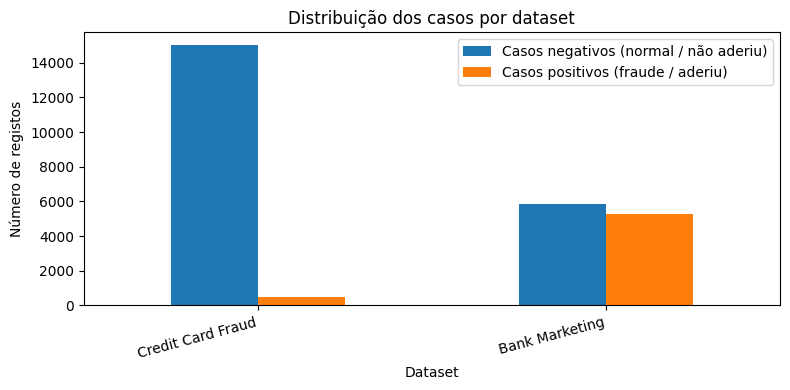

In [5]:
class_counts = summary_df.set_index("dataset")[["casos_negativos", "casos_positivos"]]
class_counts = class_counts.rename(columns={
    "casos_negativos": "Casos negativos (normal / não aderiu)",
    "casos_positivos": "Casos positivos (fraude / aderiu)",
})
ax = class_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Distribuição dos casos por dataset")
ax.set_ylabel("Número de registos")
ax.set_xlabel("Dataset")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 3. Preparação dos dados

Antes de treinar os modelos, os dados tiveram de ser preparados.

Foram aplicados estes passos:

- separação entre dados de treino e dados de teste;
- transformação das variáveis categóricas em valores numéricos;
- preparação dos atributos para serem usados pelos modelos;
- aplicação do mesmo processo aos três modelos.

Este processo garante uma comparação mais justa entre os modelos.

## 4. Modelos escolhidos

Foram usados três modelos supervisionados:

- **Logistic Regression**: modelo simples e útil como referência inicial;
- **Decision Tree**: modelo baseado em regras de decisão, mais fácil de interpretar;
- **Random Forest**: modelo mais robusto, porque combina várias árvores de decisão.

A ideia foi comparar um modelo simples, um modelo baseado em regras e um modelo mais completo.

In [6]:
print("Modelos configurados no projeto:")
for model_name in MODELS:
    print("-", model_name)

Modelos configurados no projeto:
- Logistic Regression
- Random Forest
- Decision Tree


## 5. Treino e avaliação

Nesta etapa, os três modelos são treinados nos dois conjuntos de dados.

Todos os modelos usam a mesma divisão entre treino e teste. Desta forma, os resultados podem ser comparados de forma mais correta.

In [7]:
all_results = []
per_dataset = {}

for dataset_name, (X, y) in loaded.items():
    print(f"A treinar modelos no dataset: {dataset_name}")
    results, X_test, y_test, predictions, probabilities, fitted = evaluate_dataset(dataset_name, X, y)
    all_results.append(results)
    per_dataset[dataset_name] = {
        "X_test": X_test,
        "y_test": y_test,
        "predictions": predictions,
        "probabilities": probabilities,
        "fitted": fitted,
    }

results_df = pd.concat(all_results, ignore_index=True)
results_df = results_df.sort_values(["dataset", "f1_score"], ascending=[True, False]).reset_index(drop=True)
results_df

A treinar modelos no dataset: Credit Card Fraud


A treinar modelos no dataset: Bank Marketing


,dataset,model,accuracy,precision,recall,f1_score,roc_auc,avg_precision
0,Bank Marketing,Random Forest,0.840201,0.797959,0.887292,0.840258,0.913217,0.884134
1,Bank Marketing,Logistic Regression,0.834110,0.824151,0.826021,0.825085,0.909639,0.870047
2,Bank Marketing,Decision Tree,0.825511,0.803195,0.836611,0.819563,0.866755,0.814162
3,Credit Card Fraud,Random Forest,0.995094,0.990566,0.853659,0.917031,0.977685,0.919937
4,Credit Card Fraud,Decision Tree,0.986316,0.777778,0.796748,0.787149,0.896366,0.719352
5,Credit Card Fraud,Logistic Regression,0.976246,0.581152,0.902439,0.707006,0.988180,0.923306


## 6. Resultados obtidos

A tabela seguinte compara o desempenho dos três modelos em cada dataset. Cada linha representa um modelo e cada coluna representa uma métrica de avaliação.

Os valores das métricas variam entre **0 e 1**. De forma geral, quanto mais próximo de **1**, melhor é o desempenho.

### Significado das métricas

| Métrica | Pergunta simples | Interpretação |
|---|---|---|
| **Accuracy** | O modelo acertou quantos casos no total? | Mede os acertos gerais. |
| **Precision** | Quando o modelo previu a classe positiva, estava correto? | Alta precision significa menos falsos positivos. |
| **Recall** | Dos casos positivos reais, quantos foram encontrados? | Alto recall significa menos casos positivos ignorados. |
| **F1-score** | O modelo teve bom equilíbrio entre precision e recall? | Métrica principal usada para escolher o melhor modelo. |
| **ROC-AUC** | O modelo separa bem as duas classes? | Quanto mais perto de 1, melhor distingue as classes. |
| **Average Precision** | O modelo mantém boa precision ao encontrar positivos? | Métrica útil quando existem poucos casos positivos. |

No **Credit Card Fraud**, a classe positiva corresponde a **fraude**. Por isso, além da Accuracy, são especialmente importantes a **Precision**, o **Recall**, o **F1-score** e o **Average Precision**.

In [8]:
# Tabela simplificada dos resultados
# Os valores continuam entre 0 e 1, mas são mostrados com nomes mais fáceis de interpretar.

nomes_metricas = {
    "model": "Modelo",
    "accuracy": "Accuracy - acertos gerais",
    "precision": "Precision - quando diz positivo, acerta",
    "recall": "Recall - positivos encontrados",
    "f1_score": "F1-score - equilíbrio geral",
    "roc_auc": "ROC-AUC - separa bem as classes",
    "avg_precision": "Average Precision - útil em fraude",
}

for dataset_name in results_df["dataset"].unique():
    print("\n" + "="*90)
    print(f"RESULTADOS DO DATASET: {dataset_name}")
    print("="*90)

    tabela = (
        results_df[results_df["dataset"] == dataset_name]
        .sort_values("f1_score", ascending=False)
        [["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "avg_precision"]]
        .rename(columns=nomes_metricas)
    )

    display(tabela.style.format({
        "Accuracy - acertos gerais": "{:.4f}",
        "Precision - quando diz positivo, acerta": "{:.4f}",
        "Recall - positivos encontrados": "{:.4f}",
        "F1-score - equilíbrio geral": "{:.4f}",
        "ROC-AUC - separa bem as classes": "{:.4f}",
        "Average Precision - útil em fraude": "{:.4f}",
    }))

    melhor = results_df[results_df["dataset"] == dataset_name].sort_values("f1_score", ascending=False).iloc[0]

    print("\nInterpretação principal:")
    print(f"- Melhor modelo pelo F1-score: {melhor['model']}.")
    print(f"- F1-score obtido: {melhor['f1_score']:.4f}.")
    print("- Este valor indica o melhor equilíbrio entre Precision e Recall neste dataset.")

    if dataset_name == "Credit Card Fraud":
        print("- Neste dataset, a classe positiva significa fraude.")
        print(f"- Precision = {melhor['precision']:.4f}: quando o modelo previu fraude, acertou cerca de {melhor['precision']*100:.1f}% das vezes.")
        print(f"- Recall = {melhor['recall']:.4f}: encontrou cerca de {melhor['recall']*100:.1f}% das fraudes reais.")
        print("- Como o recall não é 1.0000, ainda existiram fraudes que não foram detetadas.")
    elif dataset_name == "Bank Marketing":
        print("- Neste dataset, a classe positiva significa que o cliente aderiu ao depósito.")
        print(f"- Recall = {melhor['recall']:.4f}: encontrou cerca de {melhor['recall']*100:.1f}% dos clientes que realmente aderiram.")
        print(f"- Precision = {melhor['precision']:.4f}: quando previu adesão, acertou cerca de {melhor['precision']*100:.1f}% das vezes.")


RESULTADOS DO DATASET: Bank Marketing


,Modelo,Accuracy - acertos gerais,"Precision - quando diz positivo, acerta",Recall - positivos encontrados,F1-score - equilíbrio geral,ROC-AUC - separa bem as classes,Average Precision - útil em fraude
0,Random Forest,0.8402,0.7980,0.8873,0.8403,0.9132,0.8841
1,Logistic Regression,0.8341,0.8242,0.8260,0.8251,0.9096,0.8700
2,Decision Tree,0.8255,0.8032,0.8366,0.8196,0.8668,0.8142



Interpretação principal:
- Melhor modelo pelo F1-score: Random Forest.
- F1-score obtido: 0.8403.
- Este valor indica o melhor equilíbrio entre Precision e Recall neste dataset.
- Neste dataset, a classe positiva significa que o cliente aderiu ao depósito.
- Recall = 0.8873: encontrou cerca de 88.7% dos clientes que realmente aderiram.
- Precision = 0.7980: quando previu adesão, acertou cerca de 79.8% das vezes.

RESULTADOS DO DATASET: Credit Card Fraud


,Modelo,Accuracy - acertos gerais,"Precision - quando diz positivo, acerta",Recall - positivos encontrados,F1-score - equilíbrio geral,ROC-AUC - separa bem as classes,Average Precision - útil em fraude
3,Random Forest,0.9951,0.9906,0.8537,0.9170,0.9777,0.9199
4,Decision Tree,0.9863,0.7778,0.7967,0.7871,0.8964,0.7194
5,Logistic Regression,0.9762,0.5812,0.9024,0.7070,0.9882,0.9233



Interpretação principal:
- Melhor modelo pelo F1-score: Random Forest.
- F1-score obtido: 0.9170.
- Este valor indica o melhor equilíbrio entre Precision e Recall neste dataset.
- Neste dataset, a classe positiva significa fraude.
- Precision = 0.9906: quando o modelo previu fraude, acertou cerca de 99.1% das vezes.
- Recall = 0.8537: encontrou cerca de 85.4% das fraudes reais.
- Como o recall não é 1.0000, ainda existiram fraudes que não foram detetadas.


A tabela mostra que o **Random Forest** foi o modelo com melhor desempenho geral, porque obteve o maior **F1-score** nos dois datasets.

No caso do **Credit Card Fraud**, a Accuracy não deve ser analisada sozinha, porque existem muitas transações normais e poucas fraudes. Por isso, as métricas mais importantes são **Precision**, **Recall**, **F1-score** e **Average Precision**.

## 7. Comparação pelo F1-score

O gráfico seguinte compara os modelos através do **F1-score**.

Esta métrica é importante porque junta duas partes essenciais: encontrar os casos positivos e evitar demasiados falsos positivos.

Quanto maior for o F1-score, melhor é o equilíbrio do modelo.

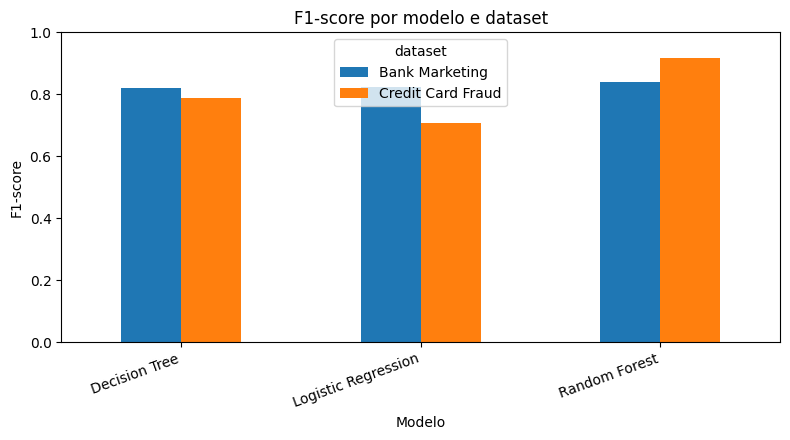

In [9]:
pivot_f1 = results_df.pivot(index="model", columns="dataset", values="f1_score")
ax = pivot_f1.plot(kind="bar", figsize=(8, 4.5))
ax.set_ylim(0, 1)
ax.set_title("F1-score por modelo e dataset")
ax.set_ylabel("F1-score")
ax.set_xlabel("Modelo")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 8. Matrizes de confusão

As matrizes de confusão mostram onde o modelo acertou e onde errou.

A leitura da matriz é feita desta forma:

| Situação | Significado |
|---|---|
| **Verdadeiro negativo** | Era classe 0 e o modelo previu classe 0. |
| **Falso positivo** | Era classe 0, mas o modelo previu classe 1. |
| **Falso negativo** | Era classe 1, mas o modelo previu classe 0. |
| **Verdadeiro positivo** | Era classe 1 e o modelo previu classe 1. |

No **Bank Marketing**, a classe positiva representa clientes que aderiram ao depósito.

No **Credit Card Fraud**, a classe positiva representa fraudes. Neste caso, os **falsos negativos** são especialmente importantes, porque representam fraudes reais que o modelo classificou como transações normais.

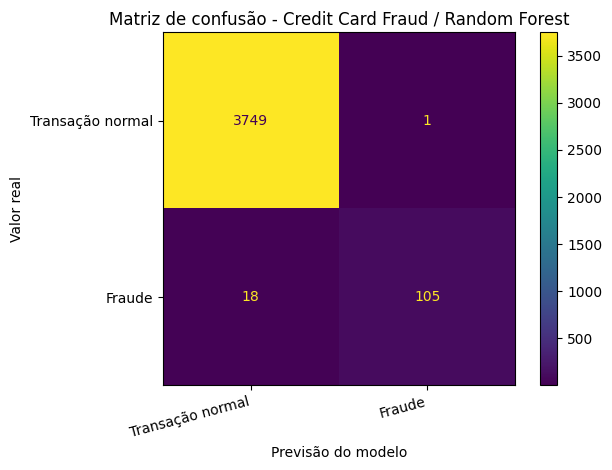

Resumo da matriz - Credit Card Fraud / Random Forest
- Verdadeiros negativos: 3749
- Falsos positivos: 1
- Falsos negativos: 18
- Verdadeiros positivos: 105
- Fraudes detetadas corretamente: 105
- Fraudes não detetadas: 18
- Em fraude, o falso negativo é o erro mais preocupante, porque significa que uma fraude passou como transação normal.



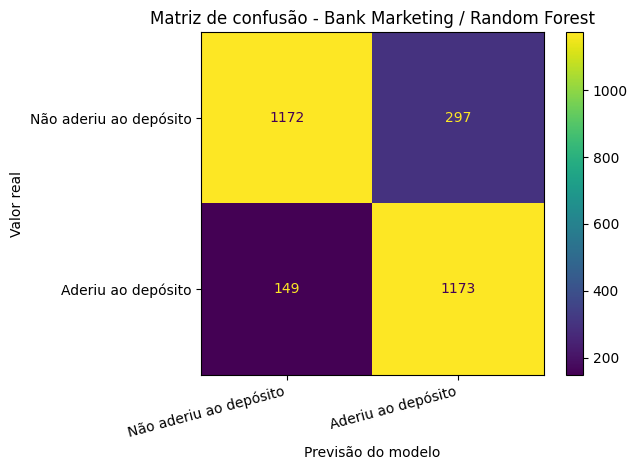

Resumo da matriz - Bank Marketing / Random Forest
- Verdadeiros negativos: 1172
- Falsos positivos: 297
- Falsos negativos: 149
- Verdadeiros positivos: 1173
- Clientes que aderiram e foram identificados corretamente: 1173
- Clientes que aderiram mas não foram identificados: 149



In [10]:
for dataset_name, data in per_dataset.items():
    best_model = results_df[results_df["dataset"] == dataset_name].sort_values("f1_score", ascending=False).iloc[0]["model"]
    y_test = data["y_test"]
    pred = data["predictions"][best_model]

    matriz = confusion_matrix(y_test, pred, labels=[0, 1])
    tn, fp, fn, tp = matriz.ravel()

    labels = list(nomes_da_variavel_alvo(dataset_name).values())
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=labels
    )
    disp.plot(values_format="d")
    plt.title(f"Matriz de confusão - {dataset_name} / {best_model}")
    plt.xlabel("Previsão do modelo")
    plt.ylabel("Valor real")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

    print(f"Resumo da matriz - {dataset_name} / {best_model}")
    print(f"- Verdadeiros negativos: {tn}")
    print(f"- Falsos positivos: {fp}")
    print(f"- Falsos negativos: {fn}")
    print(f"- Verdadeiros positivos: {tp}")

    if dataset_name == "Credit Card Fraud":
        print(f"- Fraudes detetadas corretamente: {tp}")
        print(f"- Fraudes não detetadas: {fn}")
        print("- Em fraude, o falso negativo é o erro mais preocupante, porque significa que uma fraude passou como transação normal.")
    elif dataset_name == "Bank Marketing":
        print(f"- Clientes que aderiram e foram identificados corretamente: {tp}")
        print(f"- Clientes que aderiram mas não foram identificados: {fn}")
    print()

## 9. Curvas ROC

As curvas ROC mostram a capacidade dos modelos para separar os casos negativos dos casos positivos.

O valor associado a esta curva é o **ROC-AUC**. Este valor varia entre **0 e 1**:

| Valor aproximado | Interpretação |
|---|---|
| **0.5** | Desempenho próximo do aleatório. |
| **0.7** | Desempenho razoável. |
| **0.8** | Bom desempenho. |
| **0.9 ou mais** | Muito bom desempenho. |
| **1.0** | Separação perfeita. |

Quanto mais a curva se aproxima do canto superior esquerdo e quanto maior for o **ROC-AUC**, melhor o modelo separa as duas classes.

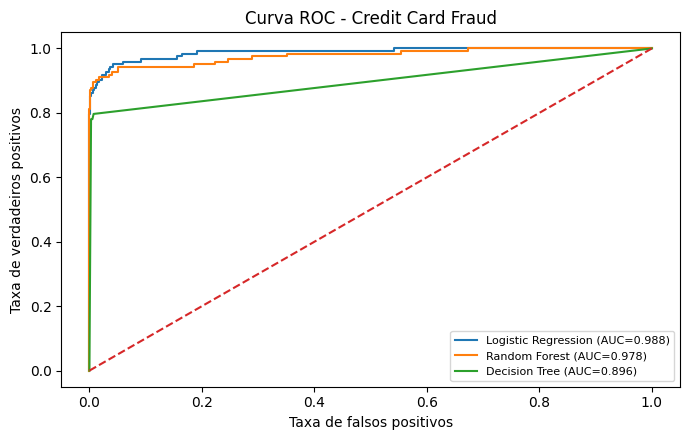

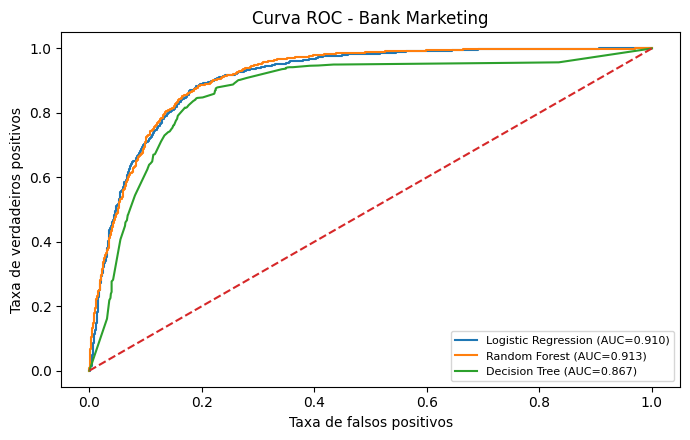

In [11]:
for dataset_name, data in per_dataset.items():
    y_test = data["y_test"]
    probabilities = data["probabilities"]

    plt.figure(figsize=(7, 4.5))
    for model_name, prob in probabilities.items():
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"Curva ROC - {dataset_name}")
    plt.xlabel("Taxa de falsos positivos")
    plt.ylabel("Taxa de verdadeiros positivos")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Curvas Precision-Recall

As curvas Precision-Recall mostram a relação entre **Precision** e **Recall**.

Esta análise é importante quando existem poucos casos positivos, como acontece no **Credit Card Fraud**, onde as fraudes são uma pequena parte das transações.

O valor associado a esta curva é o **Average Precision (AP)**. Quanto mais próximo de **1**, melhor.

O **Average Precision** resume a curva Precision-Recall. O **F1-score** também usa Precision e Recall, mas é uma métrica diferente: ele aparece na tabela principal e representa o equilíbrio das previsões finais do modelo.

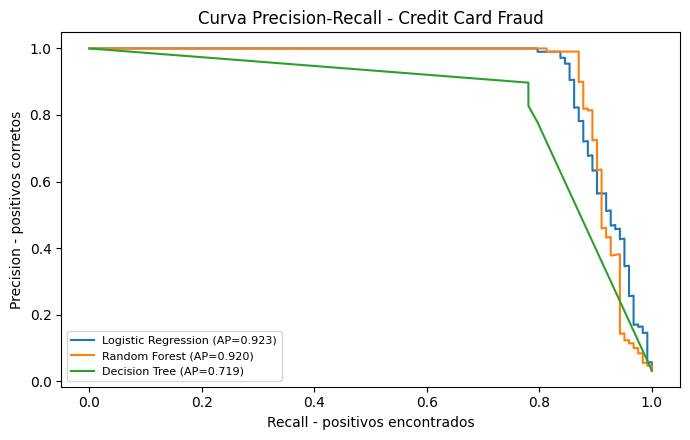

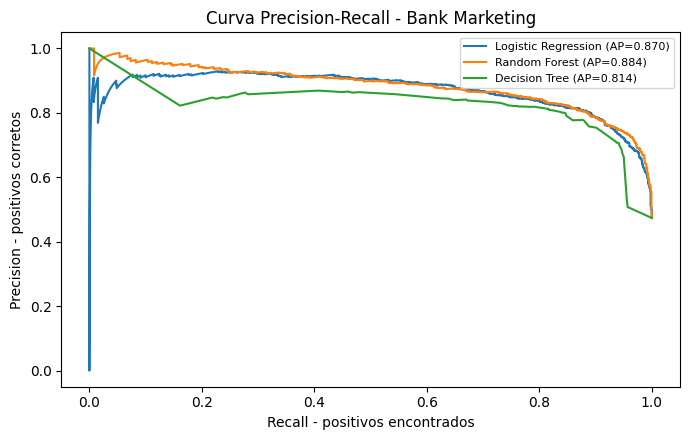

In [12]:
for dataset_name, data in per_dataset.items():
    y_test = data["y_test"]
    probabilities = data["probabilities"]

    plt.figure(figsize=(7, 4.5))
    for model_name, prob in probabilities.items():
        precision, recall, _ = precision_recall_curve(y_test, prob)
        ap = average_precision_score(y_test, prob)
        plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")
    plt.title(f"Curva Precision-Recall - {dataset_name}")
    plt.xlabel("Recall - positivos encontrados")
    plt.ylabel("Precision - positivos corretos")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 10.1 Resumo das métricas das curvas

A tabela seguinte resume os valores de **ROC-AUC** e **Average Precision** para cada modelo.

- **ROC-AUC**: mostra a capacidade geral de separar as classes.
- **Average Precision**: resume a curva Precision-Recall e é especialmente útil no dataset de fraude.

In [13]:
resumo_curvas = (
    results_df[["dataset", "model", "roc_auc", "avg_precision"]]
    .sort_values(["dataset", "avg_precision"], ascending=[True, False])
    .rename(columns={
        "dataset": "Dataset",
        "model": "Modelo",
        "roc_auc": "ROC-AUC - separação das classes",
        "avg_precision": "Average Precision - curva Precision-Recall",
    })
)

display(resumo_curvas.style.format({
    "ROC-AUC - separação das classes": "{:.4f}",
    "Average Precision - curva Precision-Recall": "{:.4f}",
}))

for dataset_name in results_df["dataset"].unique():
    melhor_ap = results_df[results_df["dataset"] == dataset_name].sort_values("avg_precision", ascending=False).iloc[0]
    melhor_auc = results_df[results_df["dataset"] == dataset_name].sort_values("roc_auc", ascending=False).iloc[0]

    print(f"\n{dataset_name}")
    print(f"- Melhor ROC-AUC: {melhor_auc['model']} ({melhor_auc['roc_auc']:.4f})")
    print(f"- Melhor Average Precision: {melhor_ap['model']} ({melhor_ap['avg_precision']:.4f})")

,Dataset,Modelo,ROC-AUC - separação das classes,Average Precision - curva Precision-Recall
0,Bank Marketing,Random Forest,0.9132,0.8841
1,Bank Marketing,Logistic Regression,0.9096,0.8700
2,Bank Marketing,Decision Tree,0.8668,0.8142
5,Credit Card Fraud,Logistic Regression,0.9882,0.9233
3,Credit Card Fraud,Random Forest,0.9777,0.9199
4,Credit Card Fraud,Decision Tree,0.8964,0.7194



Bank Marketing
- Melhor ROC-AUC: Random Forest (0.9132)
- Melhor Average Precision: Random Forest (0.8841)

Credit Card Fraud
- Melhor ROC-AUC: Logistic Regression (0.9882)
- Melhor Average Precision: Logistic Regression (0.9233)


## 11. Melhor modelo por conjunto de dados

A tabela seguinte mostra o melhor modelo em cada conjunto de dados, usando o **F1-score** como critério principal.

In [14]:
best_by_dataset = (
    results_df.sort_values("f1_score", ascending=False)
    .groupby("dataset")
    .head(1)
    .sort_values("dataset")
    .reset_index(drop=True)
)
best_by_dataset.style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
    "roc_auc": "{:.4f}",
    "avg_precision": "{:.4f}",
})

,dataset,model,accuracy,precision,recall,f1_score,roc_auc,avg_precision
0,Bank Marketing,Random Forest,0.8402,0.7980,0.8873,0.8403,0.9132,0.8841
1,Credit Card Fraud,Random Forest,0.9951,0.9906,0.8537,0.9170,0.9777,0.9199


## 12. Análise dos resultados

### Resultado principal

O **Random Forest** foi o melhor modelo nos dois datasets, porque teve o maior **F1-score**.

Isto indica que foi o modelo com melhor equilíbrio entre:

- identificar corretamente os casos positivos;
- evitar demasiados falsos positivos.

### Bank Marketing

Neste dataset, o objetivo é prever se o cliente aderiu ou não ao depósito.

O Random Forest apresentou melhor desempenho porque conseguiu um bom equilíbrio entre identificar clientes que aderiram e clientes que não aderiram.

### Credit Card Fraud

Neste dataset, o objetivo é prever se uma transação é normal ou fraudulenta.

Como existem poucas fraudes, as métricas mais importantes são:

- **Precision**: quando o modelo prevê fraude, quantas vezes está correto;
- **Recall**: das fraudes reais, quantas o modelo consegue encontrar;
- **F1-score**: equilíbrio entre Precision e Recall;
- **Average Precision**: qualidade da deteção da classe positiva ao longo da curva Precision-Recall.

O Random Forest teve uma **Precision muito alta**, ou seja, quando classificou uma transação como fraude, quase sempre estava correto.

Também teve um **Recall bom**, porque conseguiu encontrar grande parte das fraudes reais.

### Comparação com outros modelos

A Logistic Regression pode apresentar Recall mais alto no dataset de fraude, porque consegue encontrar mais fraudes. No entanto, isso pode vir acompanhado de mais falsos positivos.

O Random Forest foi escolhido porque teve o melhor **F1-score**, ou seja, o melhor equilíbrio geral entre detetar fraudes e evitar falsos alarmes.

## 13. Conclusão

A conclusão principal é:

> O **Random Forest** foi o modelo mais consistente.

Este modelo teve o melhor **F1-score** nos dois datasets, mostrando o melhor equilíbrio geral entre Precision e Recall.

No caso da deteção de fraude, não basta analisar apenas a Accuracy, porque existem muitas transações normais e poucas fraudes. É importante confirmar se o modelo consegue encontrar fraudes reais sem gerar demasiados falsos alarmes.

Como melhoria futura, seria possível testar mais dados, ajustar parâmetros dos modelos e procurar reduzir o número de fraudes não detetadas.